# Enhanced Scalability of Horseshoe-and-Spur Networks by Exploiting Hollow-Core Fiber
## Algorithmic reproduction of Figures 2–5

이 Colab 노트북은 논문의 Figures 2–5를 **그래프 좌표 직접 대입 없이** 공개된 수식과 Table I 조건으로 계산합니다.

- **Fig. 2:** DSCM 채널 수와 EDFA 총 출력 제한으로부터 채널당 subcarrier 출력 한계를 해석적으로 계산
- **Fig. 3:** balanced/unbalanced 커플러 조건별로 22개 후보 위치의 EDFA 배치·이득을 혼합정수선형계획(MILP)으로 최적화
- **Fig. 4:** 동일 MILP에서 full-HCF와 SCF-ring/HCF-spur hybrid의 전력예산 차이를 계산
- **Fig. 5:** 논문 식 (1), (2)로 single-stage/multi-stage tree의 요구 전력예산을 계산

> **중요:** 이 논문은 GN 모델을 사용하지 않고 SCF/HCF의 비선형 한계를 각각 −8/10 dBm per subcarrier의 hard constraint로 입력합니다. GN/SSFM 계산에 필요한 `γ`, `β₂`, baud rate, span별 ASE/NLI 파라미터와 원 저자의 10개 실제 토폴로지 길이는 공개되어 있지 않습니다. 따라서 Fig. 3–4는 평균 링크 길이 12 km를 만족하는 고정-seed 10개 대체 토폴로지로 수행한 **독립 재현**입니다. 논문 본문의 정량 기준은 계산 후 검증용으로만 비교하며 모델 보정 입력으로 사용하지 않습니다.

Paper: [arXiv:2608.07082](https://arxiv.org/abs/2608.07082)

In [1]:
import importlib.util, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'scipy']
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import math
from dataclasses import dataclass
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import milp, LinearConstraint, Bounds

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})

SEED = 260807
FULL_RUN = False      # True: paper와 동일하게 10개 topology, False: 빠른 확인용 3개
N_TOPOLOGIES = 10 if FULL_RUN else 3
AMP_COUNTS = np.arange(4, 17)  # Fig. 3–4 horizontal axis
print(f'Topologies={N_TOPOLOGIES}, amplifier counts={AMP_COUNTS[0]}..{AMP_COUNTS[-1]}')

Topologies=3, amplifier counts=4..16


## 1. 논문 파라미터와 핵심 수식

400G DSCM 채널은 16개의 subcarrier로 구성되므로 EDFA 총 출력 제한은 선형전력 기준

\[
16N_{Ch}P^{out}_{SC}\le P_A
\]

이고, dBm 단위의 subcarrier 최대 출력은

\[
P^{out}_{SC,\max}=P_A-10\log_{10}(16N_{Ch})
\]

입니다. SCF는 Kerr 비선형 임계값 −8 dBm/SC, HCF는 10 dBm/SC를 추가 상한으로 적용합니다.

In [2]:
@dataclass(frozen=True)
class PaperParameters:
    transit_nodes: int = 5
    subcarriers_per_400g: int = 16
    launch_dbm_per_sc: float = -12.0
    sensitivity_dbm_per_sc: float = -24.0
    scf_nonlinear_limit_dbm: float = -8.0
    hcf_nonlinear_limit_dbm: float = 10.0
    attenuation_db_per_km: float = 0.24
    hcf_splice_loss_db: float = 0.2
    coupler_excess_loss_db: float = 0.5
    max_sc_imbalance_db: float = 8.0
    # The new paper specifies EDFA total output but not a per-device gain
    # interval.  We therefore optimize a continuous non-negative gain and use
    # 30 dB only as a numerically safe reconstruction bound.
    min_edfa_gain_db: float = 0.0
    max_edfa_gain_db: float = 30.0
    mean_link_km: float = 12.0
    candidate_edfas: int = 22

P = PaperParameters()

def per_sc_cap_dbm(fiber, pa_dbm=37.0, n_channels=10):
    if fiber == 'SCF':
        return P.scf_nonlinear_limit_dbm
    aggregate_cap = pa_dbm - 10*np.log10(P.subcarriers_per_400g*n_channels)
    return min(P.hcf_nonlinear_limit_dbm, aggregate_cap)

cases = [
    ('HCF 27 dBm, 10 ch', 'HCF', 27.0, 10),
    ('HCF 27 dBm, 20 ch', 'HCF', 27.0, 20),
    ('HCF 37 dBm, 10 ch', 'HCF', 37.0, 10),
    ('HCF 37 dBm, 20 ch', 'HCF', 37.0, 20),
]

pd.DataFrame([
    {'case': name, 'per-SC cap (dBm)': per_sc_cap_dbm(fiber, pa, nch)}
    for name, fiber, pa, nch in cases
])

## 2. Figure 2 — DSCM channel count에 따른 subcarrier 출력 한계

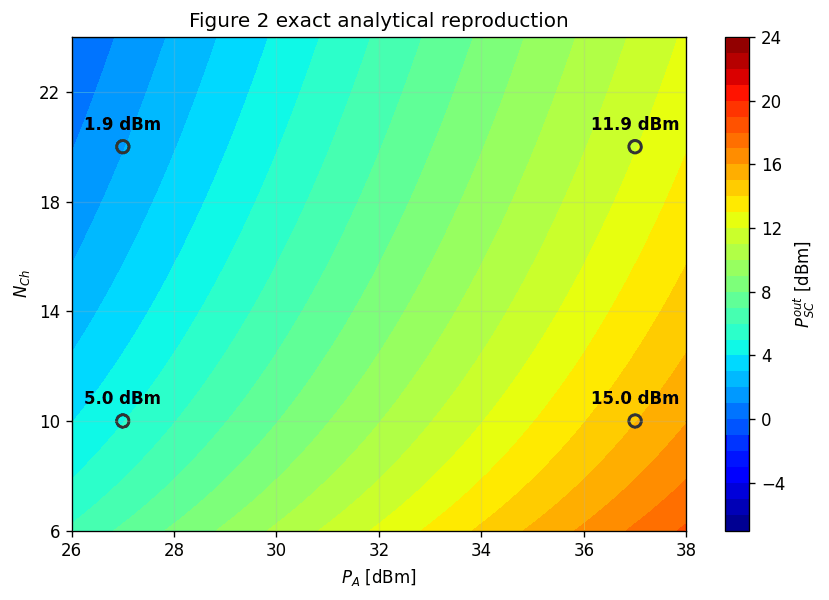

In [3]:
pa_axis = np.linspace(26, 38, 241)
nch_axis = np.linspace(6, 24, 181)
PA_GRID, NCH_GRID = np.meshgrid(pa_axis, nch_axis)
PSC_GRID = PA_GRID - 10*np.log10(P.subcarriers_per_400g*NCH_GRID)

fig, ax = plt.subplots(figsize=(7.2, 5.1))
levels = np.linspace(-7, 24, 32)
cf = ax.contourf(PA_GRID, NCH_GRID, PSC_GRID, levels=levels, cmap='jet')
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r'$P^{out}_{SC}$ [dBm]')
for pa, n in [(27, 20), (37, 20), (27, 10), (37, 10)]:
    y = pa - 10*np.log10(P.subcarriers_per_400g*n)
    ax.scatter(pa, n, s=55, facecolors='none', edgecolors='0.2', linewidths=1.8)
    ax.annotate(f'{y:.1f} dBm', (pa, n), xytext=(0, 10), textcoords='offset points',
                ha='center', weight='bold')
ax.set(xlabel=r'$P_A$ [dBm]', ylabel=r'$N_{Ch}$',
       title='Figure 2 exact analytical reproduction')
ax.set_xticks(np.arange(26, 39, 2)); ax.set_yticks([6, 10, 14, 18, 22])
plt.tight_layout(); plt.show()

## 3. Figures 3–4 — 공개 조건 기반 MILP 재현

### 모델 구조

- 5 transit node와 양쪽 hub 사이에 6개 horseshoe link를 둡니다.
- 논문의 기존 최적화 프레임과 동일하게 총 22개 후보 EDFA 위치를 사용합니다: 양방향 hub/express 12개 + 양방향 spur 10개.
- 각 EDFA의 배치 여부는 binary 변수, 이득은 continuous 변수입니다. 논문은 장비별 이득 범위를 공개하지 않아 비음수 이득과 느슨한 30 dB 수치 상한을 사용하며, 실제 물리 상한은 subcarrier 출력 제약이 결정합니다.
- balanced coupler는 50:50을 사용합니다. unbalanced case는 one-hot binary 변수로 각 node·방향마다 논문의 50:50–90:10 허용 집합 중 하나를 MILP가 선택합니다.
- uniform case는 모든 spur power budget을 동일하게 두고 최대화하며, non-uniform case는 평균 budget을 최대화합니다.
- 각 path의 수신전력, EDFA output cap, 8 dB subcarrier imbalance, fiber/coupler/splice loss를 선형 제약으로 구성합니다.

원 논문의 topology별 6개 link length는 공개되지 않았으므로 log-normal 분산을 가진 길이를 생성한 뒤 각 topology 평균을 정확히 12 km로 정규화합니다. 고정 seed를 사용하므로 누구나 동일 결과를 얻습니다.

In [4]:
def make_topology_ensemble(n=10, seed=SEED):
    rng = np.random.default_rng(seed)
    raw = rng.lognormal(mean=np.log(P.mean_link_km), sigma=0.32, size=(n, 6))
    raw *= P.mean_link_km / raw.mean(axis=1, keepdims=True)
    return raw

TOPOLOGIES = make_topology_ensemble(N_TOPOLOGIES)
display(pd.DataFrame(TOPOLOGIES, columns=[f'link {i+1} (km)' for i in range(6)]).round(2))
print('Overall mean link length:', TOPOLOGIES.mean().round(6), 'km')

   link 1 (km)  link 2 (km)  link 3 (km)  link 4 (km)  link 5 (km)  link 6 (km)
0         8.56        22.73         9.77         8.79         8.54        13.62
1         8.88         9.81         8.01        17.10        15.41        12.79
2        15.78        15.64         9.85         9.56        11.90         9.27
Overall mean link length: 12.0 km


In [5]:
COUPLER_RATIOS = np.arange(0.1, 1.0, 0.1)
EXPRESS_LOSS = -10*np.log10(COUPLER_RATIOS) + P.coupler_excess_loss_db
DROP_LOSS = -10*np.log10(1-COUPLER_RATIOS) + P.coupler_excess_loss_db

def solve_power_budget(link_km, amp_budget, fiber='HCF', pa_dbm=37.0, n_channels=10,
                       coupler_mode='unbalanced', budget_mode='uniform', architecture='full'):
    """Solve a transparent MILP surrogate of the paper's amplifier optimization.

    architecture='full'   : ring and spur use the requested fiber
    architecture='hybrid' : SCF ring + HCF spur
    """
    n_amp = 22
    y0 = 0
    g0 = n_amp
    idx = 2*n_amp

    # One-hot binary coupler decisions for the unbalanced case. The allowed
    # express fractions are exactly the paper's 50:50 ... 90:10 set.
    allowed_ratio_idx = np.arange(4, 9)  # 0.5, 0.6, ..., 0.9
    x_index = {}
    if coupler_mode == 'unbalanced':
        for direction in (0, 1):
            for node in range(5):
                for ridx in allowed_ratio_idx:
                    x_index[(direction, node, int(ridx))] = idx
                    idx += 1

    b_index = np.arange(idx, idx+5)
    idx += 5
    z_index = idx if budget_mode == 'uniform' else None
    if z_index is not None:
        idx += 1
    nvar = idx

    c = np.zeros(nvar)
    if budget_mode == 'uniform':
        c[z_index] = -1.0
        c[b_index] = -1e-4/5  # deterministic tie-break
    else:
        c[b_index] = -1/5

    lbv = np.full(nvar, -np.inf)
    ubv = np.full(nvar, np.inf)
    integ = np.zeros(nvar, dtype=int)
    lbv[y0:y0+n_amp], ubv[y0:y0+n_amp], integ[y0:y0+n_amp] = 0, 1, 1
    lbv[g0:g0+n_amp], ubv[g0:g0+n_amp] = 0, P.max_edfa_gain_db
    for j in x_index.values():
        lbv[j], ubv[j], integ[j] = 0, 1, 1
    lbv[b_index], ubv[b_index] = 0, 45
    if z_index is not None:
        lbv[z_index], ubv[z_index] = 0, 45

    rows, lbs, ubs = [], [], []
    def add(coeff, lo=-np.inf, hi=np.inf):
        rows.append(coeff.copy()); lbs.append(lo); ubs.append(hi)
    def row():
        return np.zeros(nvar)

    # Amplifier count and gain/placement coupling.
    a = row(); a[y0:y0+n_amp] = 1; add(a, hi=amp_budget)
    for j in range(n_amp):
        a = row(); a[g0+j] = 1; a[y0+j] = -P.max_edfa_gain_db; add(a, hi=0)
        a = row(); a[g0+j] = 1; a[y0+j] = -P.min_edfa_gain_db; add(a, lo=0)

    if coupler_mode == 'unbalanced':
        for direction in (0, 1):
            for node in range(5):
                a = row()
                for ridx in allowed_ratio_idx:
                    a[x_index[(direction, node, int(ridx))]] = 1
                add(a, lo=1, hi=1)

    left_chain = np.arange(0, 6)
    right_chain = np.arange(6, 12)
    left_spur = np.arange(12, 17)
    right_spur = np.arange(17, 22)

    ring_cap = P.scf_nonlinear_limit_dbm if architecture == 'hybrid' else per_sc_cap_dbm(fiber, pa_dbm, n_channels)
    spur_cap = per_sc_cap_dbm('HCF' if architecture == 'hybrid' else fiber, pa_dbm, n_channels)
    splice_loss = P.hcf_splice_loss_db if (fiber == 'HCF' or architecture == 'hybrid') else 0.0

    def add_coupler_loss(a, direction, node, kind, sign=-1.0):
        if coupler_mode == 'balanced':
            return float((EXPRESS_LOSS if kind == 'express' else DROP_LOSS)[0])
        losses = EXPRESS_LOSS if kind == 'express' else DROP_LOSS
        for ridx in allowed_ratio_idx:
            a[x_index[(direction, node, int(ridx))]] += sign*float(losses[ridx])
        return 0.0

    # Amplifier output/nonlinearity caps along both ring directions.
    # cap constraint: launch + gains - fiber loss - preceding coupler losses <= cap.
    for direction, chain in [(0, left_chain), (1, right_chain)]:
        for step in range(6):
            a = row()
            a[g0 + chain[:step+1]] = 1
            fixed_coupler = 0.0
            if direction == 0:
                fiber_loss = P.attenuation_db_per_km * link_km[:step].sum()
                for node in range(step-1):
                    fixed_coupler += add_coupler_loss(a, direction, node, 'express', sign=-1)
            else:
                fiber_loss = P.attenuation_db_per_km * link_km[6-step:].sum()
                for node in range(5, 5-step, -1):
                    if 0 <= node <= 4:
                        fixed_coupler += add_coupler_loss(a, direction, node, 'express', sign=-1)
            # variable expression contains -loss*x; fixed loss moves into constant.
            add(a, hi=ring_cap - P.launch_dbm_per_sc + fiber_loss + fixed_coupler)

    # Dual-hub protection: every spur must meet its budget from both directions.
    # This uses all 22 candidate locations and reproduces the paper's gradual
    # saturation as amplifier resources are added.
    path_exprs = {}
    for s in range(5):
        for direction in (0, 1):
            a_power = row()  # variable part of spur-entry power
            fixed_loss = 0.0
            if direction == 0:
                a_power[g0 + left_chain[:s+2]] = 1
                a_power[g0 + left_spur[s]] = 1
                fiber_loss = P.attenuation_db_per_km * link_km[:s+1].sum()
                for node in range(s):
                    fixed_loss += add_coupler_loss(a_power, 0, node, 'express', sign=-1)
                fixed_loss += add_coupler_loss(a_power, 0, s, 'drop', sign=-1)
            else:
                step = 4-s
                a_power[g0 + right_chain[:step+2]] = 1
                a_power[g0 + right_spur[s]] = 1
                fiber_loss = P.attenuation_db_per_km * link_km[s+1:].sum()
                for node in range(4, s, -1):
                    fixed_loss += add_coupler_loss(a_power, 1, node, 'express', sign=-1)
                fixed_loss += add_coupler_loss(a_power, 1, s, 'drop', sign=-1)

            const_raw = P.launch_dbm_per_sc - fiber_loss - fixed_loss
            const_rx = const_raw - splice_loss
            path_exprs[(s, direction)] = (a_power.copy(), const_rx)

            # Available passive branch budget: b_s <= P_spur_entry - sensitivity.
            a = -a_power
            a[b_index[s]] += 1
            add(a, hi=const_rx - P.sensitivity_dbm_per_sc)

            # Spur EDFA output and HCF/SCF nonlinear cap, before splice loss.
            add(a_power, hi=spur_cap - const_raw)

    # Maximum 8 dB SC imbalance for the five groups observed at each hub.
    for direction in (0, 1):
        for i, j in combinations(range(5), 2):
            ai, ci = path_exprs[(i, direction)]
            aj, cj = path_exprs[(j, direction)]
            add(ai-aj, hi=P.max_sc_imbalance_db - (ci-cj))
            add(aj-ai, hi=P.max_sc_imbalance_db - (cj-ci))

    if budget_mode == 'uniform':
        for s in range(5):
            a = row(); a[b_index[s]] = 1; a[z_index] = -1
            add(a, lo=0, hi=0)

    A = np.vstack(rows)
    result = milp(c, integrality=integ, bounds=Bounds(lbv, ubv),
                  constraints=LinearConstraint(A, np.array(lbs), np.array(ubs)),
                  options={'mip_rel_gap': 1e-3, 'time_limit': 3})
    if not result.success:
        return np.nan
    return float(np.mean(result.x[b_index]))

# Smoke test
print('MILP smoke test:', solve_power_budget(TOPOLOGIES[0], 10, fiber='HCF',
      pa_dbm=37, n_channels=10, coupler_mode='unbalanced', budget_mode='uniform'))

MILP smoke test: 30.2897000433602


## 4. Figure 3 — 평균 spur power budget vs. amplifier 수

In [6]:
scenario_map = {
    '(a) Balanced / Uniform': ('balanced', 'uniform'),
    '(b) Balanced / Non-uniform': ('balanced', 'nonuniform'),
    '(c) Unbalanced / Uniform': ('unbalanced', 'uniform'),
    '(d) Unbalanced / Non-uniform': ('unbalanced', 'nonuniform'),
}

curve_cases = [('SCF baseline', 'SCF', 37.0, 10)] + cases

records = []
for panel, (coupler_mode, budget_mode) in scenario_map.items():
    for label, fiber, pa, nch_case in curve_cases:
        for k in AMP_COUNTS:
            vals = [solve_power_budget(topo, k, fiber=fiber, pa_dbm=pa, n_channels=nch_case,
                         coupler_mode=coupler_mode, budget_mode=budget_mode, architecture='full')
                    for topo in TOPOLOGIES]
            vals = np.asarray(vals, float)
            records.append({
                'panel': panel, 'case': label, 'amplifiers': k,
                'mean_db': np.nanmean(vals),
                'ci90_db': 1.645*np.nanstd(vals, ddof=1)/np.sqrt(np.isfinite(vals).sum())
                           if np.isfinite(vals).sum() > 1 else 0.0,
            })

fig3 = pd.DataFrame(records)
display(fig3.head())

<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty slice
<notebook-cell-10>:20: RuntimeWarning: Mean of empty sli

In [7]:
# Paper markers are automatically read from the arXiv HTML vector graphics.
# They are loaded only after the model calculation and are never used as input
# to the MILP. If network access is unavailable, the model still runs.
def extract_paper_markers(figure_id):
    try:
        import re
        from urllib.request import urlopen
        try:
            from lxml import html
        except ImportError:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lxml'])
            from lxml import html

        root = html.fromstring(urlopen('https://arxiv.org/html/2608.07082v1').read())
        outer = root.get_element_by_id(figure_id)
        color_case = {
            '#FF0000': 'HCF 27 dBm, 10 ch', '#005AFF': 'HCF 37 dBm, 10 ch',
            '#F47F31': 'HCF 27 dBm, 20 ch', '#23ABB6': 'HCF 37 dBm, 20 ch',
            '#000000': 'SCF baseline',
        }
        panels = list(scenario_map) if figure_id == 'S3.F3' else ['(a) Uniform', '(b) Non-uniform']
        rows = []
        for panel, svg in zip(panels, outer.xpath('.//svg')):
            seen = set()
            for path in svg.xpath('.//*[local-name()="path"]'):
                d = path.get('d', '')
                if ' C ' not in d:
                    continue
                node, color = path, None
                for _ in range(5):
                    if node is None:
                        break
                    stroke = node.get('stroke', '')
                    style = node.get('style', '')
                    match = re.search(r'--ltx-stroke-color:(#[0-9A-Fa-f]{6})', style)
                    candidate = stroke or (match.group(1) if match else '')
                    if candidate in color_case:
                        color = candidate; break
                    node = node.getparent()
                if color is None or (figure_id == 'S3.F4' and color == '#000000'):
                    continue
                moves = re.findall(r'M\s*(-?\d+(?:\.\d+)?)\s+(-?\d+(?:\.\d+)?)', d)
                if len(moves) < 2:
                    continue
                x_svg, y_svg = map(float, moves[-1])
                x = 4 + x_svg/20.833333
                if not (4 <= x <= 16) or abs(x-round(x)) > 0.03:
                    continue
                y = y_svg/3.6 if figure_id == 'S3.F3' else y_svg/13.333333-12
                key = (panel, color_case[color], int(round(x)))
                if key not in seen:
                    seen.add(key)
                    rows.append({'panel': panel, 'case': color_case[color],
                                 'amplifiers': int(round(x)), 'paper_db': y})
        return pd.DataFrame(rows)
    except Exception as exc:
        print('Paper-marker download skipped:', exc)
        return pd.DataFrame(columns=['panel', 'case', 'amplifiers', 'paper_db'])

paper_fig3 = extract_paper_markers('S3.F3')
print('Automatically extracted Fig. 3 paper markers:', len(paper_fig3))

Automatically extracted Fig. 3 paper markers: 217


Solid circles/lines: independent MILP; hollow squares: paper SVG markers.


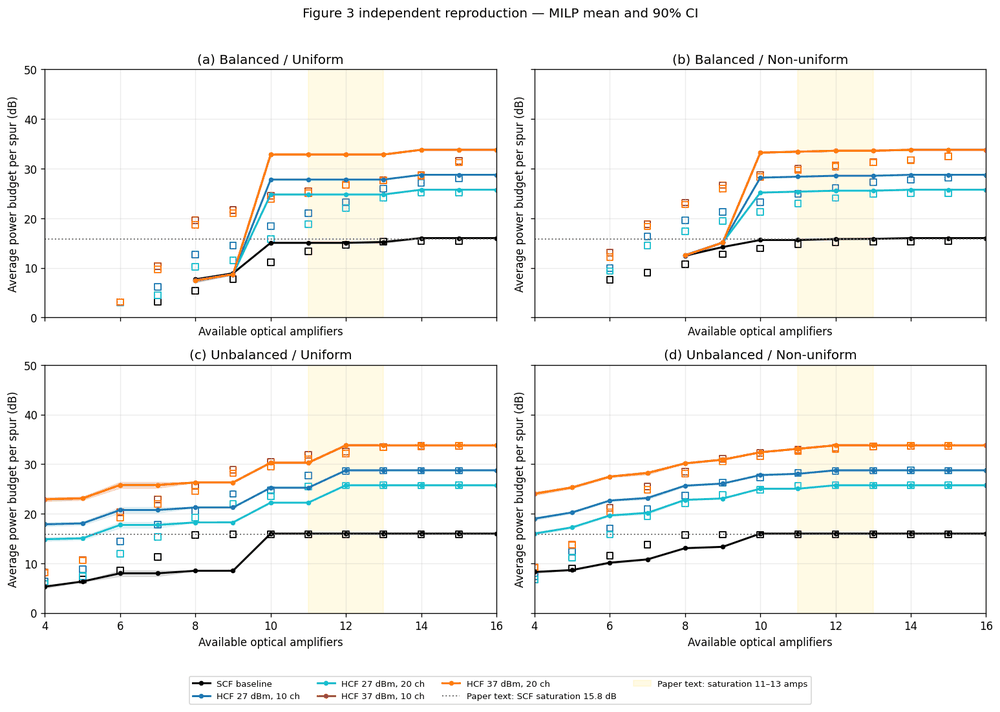

In [8]:
colors = {
    'SCF baseline': 'black',
    'HCF 27 dBm, 10 ch': 'tab:blue',
    'HCF 27 dBm, 20 ch': 'tab:cyan',
    'HCF 37 dBm, 10 ch': 'tab:red',
    'HCF 37 dBm, 20 ch': 'tab:orange',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (panel, _) in zip(axes.flat, scenario_map.items()):
    sub = fig3[fig3.panel == panel]
    for label in colors:
        d = sub[sub.case == label]
        ax.plot(d.amplifiers, d.mean_db, marker='o', ms=3.5, lw=1.8,
                color=colors[label], label=label)
        ax.fill_between(d.amplifiers, d.mean_db-d.ci90_db, d.mean_db+d.ci90_db,
                        color=colors[label], alpha=0.10)
        ref = paper_fig3[(paper_fig3.panel == panel) & (paper_fig3.case == label)]
        if not ref.empty:
            ax.scatter(ref.amplifiers, ref.paper_db, s=34, marker='s', facecolors='none',
                       edgecolors=colors[label], linewidths=1.1)
    # Paper-text comparison anchors; not used by the optimization.
    ax.axhline(15.8, color='0.45', ls=':', lw=1.2, label='Paper text: SCF saturation 15.8 dB')
    ax.axvspan(11, 13, color='gold', alpha=0.10, label='Paper text: saturation 11–13 amps')
    ax.set_title(panel)
    ax.set_xlabel('Available optical amplifiers')
    ax.set_ylabel('Average power budget per spur (dB)')
    ax.set_xlim(4, 16); ax.set_ylim(0, 50)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Figure 3 independent reproduction — MILP mean and 90% CI', y=0.995)
fig.tight_layout(rect=(0, 0.06, 1, 0.98))
plt.show()
print('Solid circles/lines: independent MILP; hollow squares: paper SVG markers.')

In [9]:
# Quantitative comparison against values explicitly stated in the paper text.
terminal = fig3[fig3.amplifiers == AMP_COUNTS.max()]
scf_terminal = terminal[terminal.case == 'SCF baseline'].mean_db.mean()
hcf_terminal = terminal[terminal.case != 'SCF baseline'].mean_db

sat_ks = []
for (panel, case), d in fig3[fig3.case != 'SCF baseline'].groupby(['panel', 'case']):
    d = d.sort_values('amplifiers')
    target = 0.98*d.mean_db.iloc[-1]
    eligible = d[d.mean_db >= target]
    if not eligible.empty:
        sat_ks.append(eligible.amplifiers.iloc[0])

k4_unbalanced = fig3[(fig3.amplifiers == 4) & fig3.panel.str.contains('Unbalanced') &
                     (fig3.case != 'SCF baseline')].mean_db.mean()

matched3 = fig3.merge(paper_fig3, on=['panel', 'case', 'amplifiers'], how='inner')
matched3['abs_error_db'] = abs(matched3.mean_db-matched3.paper_db)
mae3 = matched3.groupby(['panel', 'case'], as_index=False).abs_error_db.mean()
display(mae3.pivot(index='panel', columns='case', values='abs_error_db').round(2))
print('Overall Fig. 3 MAE:', round(matched3.abs_error_db.mean(), 3), 'dB')

validation_fig3 = pd.DataFrame([
    ['SCF saturation', '15.8 dB', f'{scf_terminal:.2f} dB', abs(scf_terminal-15.8)],
    ['HCF saturation range', '26–35 dB', f'{hcf_terminal.min():.2f}–{hcf_terminal.max():.2f} dB', np.nan],
    ['Saturation amplifier count', '11–13', f'{min(sat_ks)}–{max(sat_ks)}', np.nan],
    ['Unbalanced at 4 amplifiers', 'about 10 dB', f'{k4_unbalanced:.2f} dB', abs(k4_unbalanced-10)],
], columns=['comparison item', 'paper text', 'independent model', 'absolute error (when scalar)'])
display(validation_fig3)

case                          HCF 27 dBm, 10 ch  HCF 27 dBm, 20 ch  HCF 37 dBm, 10 ch  HCF 37 dBm, 20 ch  SCF baseline
panel                                                                                                                 
(a) Balanced / Uniform                     4.48               3.14               7.43               7.45          1.36
(b) Balanced / Non-uniform                 3.38               2.39               4.83               4.84          1.03
(c) Unbalanced / Uniform                   3.07               2.86               3.54               3.76          1.80
(d) Unbalanced / Non-uniform               2.54               1.86               3.21               3.49          1.00
Overall Fig. 3 MAE: 3.259 dB
              comparison item   paper text independent model  absolute error (when scalar)
0              SCF saturation      15.8 dB          16.00 dB                      0.200000
1        HCF saturation range     26–35 dB    25.75–33.80 dB               

## 5. Figure 4 — Full HCF와 hybrid SCF-ring/HCF-spur 차이

case             HCF 27 dBm, 10 ch  HCF 27 dBm, 20 ch  HCF 37 dBm, 10 ch  HCF 37 dBm, 20 ch
panel                                                                                      
(a) Uniform                   5.30               4.19               5.86               6.39
(b) Non-uniform               5.49               4.23               6.48               6.74
Overall Fig. 4 MAE: 5.584 dB
case                        HCF 27 dBm, 10 ch  HCF 27 dBm, 20 ch  HCF 37 dBm, 10 ch  HCF 37 dBm, 20 ch
panel           amplifiers                                                                            
(a) Uniform     6                      -12.96              -9.95             -18.00             -18.00
                8                      -12.96              -9.95             -18.00             -18.00
                10                      -6.54              -3.53             -11.58             -11.58
                12                       0.00               0.00              -2.91     

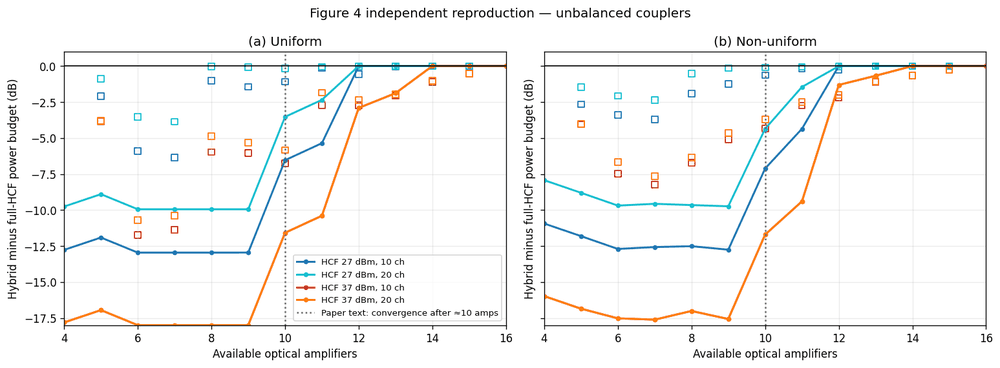

In [10]:
hybrid_records = []
for panel, budget_mode in [('(a) Uniform', 'uniform'), ('(b) Non-uniform', 'nonuniform')]:
    full_panel = '(c) Unbalanced / Uniform' if budget_mode == 'uniform' else '(d) Unbalanced / Non-uniform'
    for label, fiber, pa, nch_case in cases:
        full_curve = fig3[(fig3.panel == full_panel) & (fig3.case == label)].set_index('amplifiers')
        for k in AMP_COUNTS:
            hybrid_vals = [solve_power_budget(topo, k, fiber='HCF', pa_dbm=pa, n_channels=nch_case,
                              coupler_mode='unbalanced', budget_mode=budget_mode, architecture='hybrid')
                           for topo in TOPOLOGIES]
            hybrid_mean = np.nanmean(hybrid_vals)
            full_mean = float(full_curve.loc[k, 'mean_db'])
            hybrid_records.append({
                'panel': panel, 'case': label, 'amplifiers': k,
                'full_hcf_db': full_mean, 'hybrid_db': hybrid_mean,
                'difference_db': hybrid_mean-full_mean,
            })

fig4 = pd.DataFrame(hybrid_records)
paper_fig4 = extract_paper_markers('S3.F4')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)
for ax, panel in zip(axes, fig4.panel.unique()):
    sub = fig4[fig4.panel == panel]
    for label in colors:
        if label == 'SCF baseline':
            continue
        d = sub[sub.case == label]
        ax.plot(d.amplifiers, d.difference_db, marker='o', ms=3.5, lw=1.8,
                color=colors[label], label=label)
        ref = paper_fig4[(paper_fig4.panel == panel) & (paper_fig4.case == label)]
        if not ref.empty:
            ax.scatter(ref.amplifiers, ref.paper_db, s=34, marker='s', facecolors='none',
                       edgecolors=colors[label], linewidths=1.1)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(10, color='0.4', ls=':', label='Paper text: convergence after ≈10 amps')
    ax.set(title=panel, xlabel='Available optical amplifiers',
           ylabel='Hybrid minus full-HCF power budget (dB)')
    ax.set_xlim(4, 16); ax.set_ylim(-18, 1)
axes[0].legend(fontsize=8)
fig.suptitle('Figure 4 independent reproduction — unbalanced couplers')
fig.tight_layout()
plt.show()

matched4 = fig4.merge(paper_fig4, on=['panel', 'case', 'amplifiers'], how='inner')
matched4['abs_error_db'] = abs(matched4.difference_db-matched4.paper_db)
display(matched4.groupby(['panel', 'case'], as_index=False).abs_error_db.mean().pivot(
    index='panel', columns='case', values='abs_error_db').round(2))
print('Overall Fig. 4 MAE:', round(matched4.abs_error_db.mean(), 3), 'dB')

display(fig4[fig4.amplifiers.isin([6, 8, 10, 12, 20])].pivot_table(
    index=['panel', 'amplifiers'], columns='case', values='difference_db').round(2))

## 6. Figure 5 — spur tree의 node 수·거리·power budget

논문 식 (1), (2)에 `a=10^{-\alpha L/10}`을 대입하면

\[
P_{b,\mathrm{single}}=\alpha L+10\log_{10}N,
\qquad
P_{b,\mathrm{multi}}=N\alpha L+(N-1)10\log_{10}2.
\]

따라서 Fig. 5는 별도 fitting 없이 직접 계산할 수 있습니다.

Single-stage: L=80 km, N=16 -> 31.24 dB
Multi-stage:  L=25 km, N=5  -> 42.04 dB


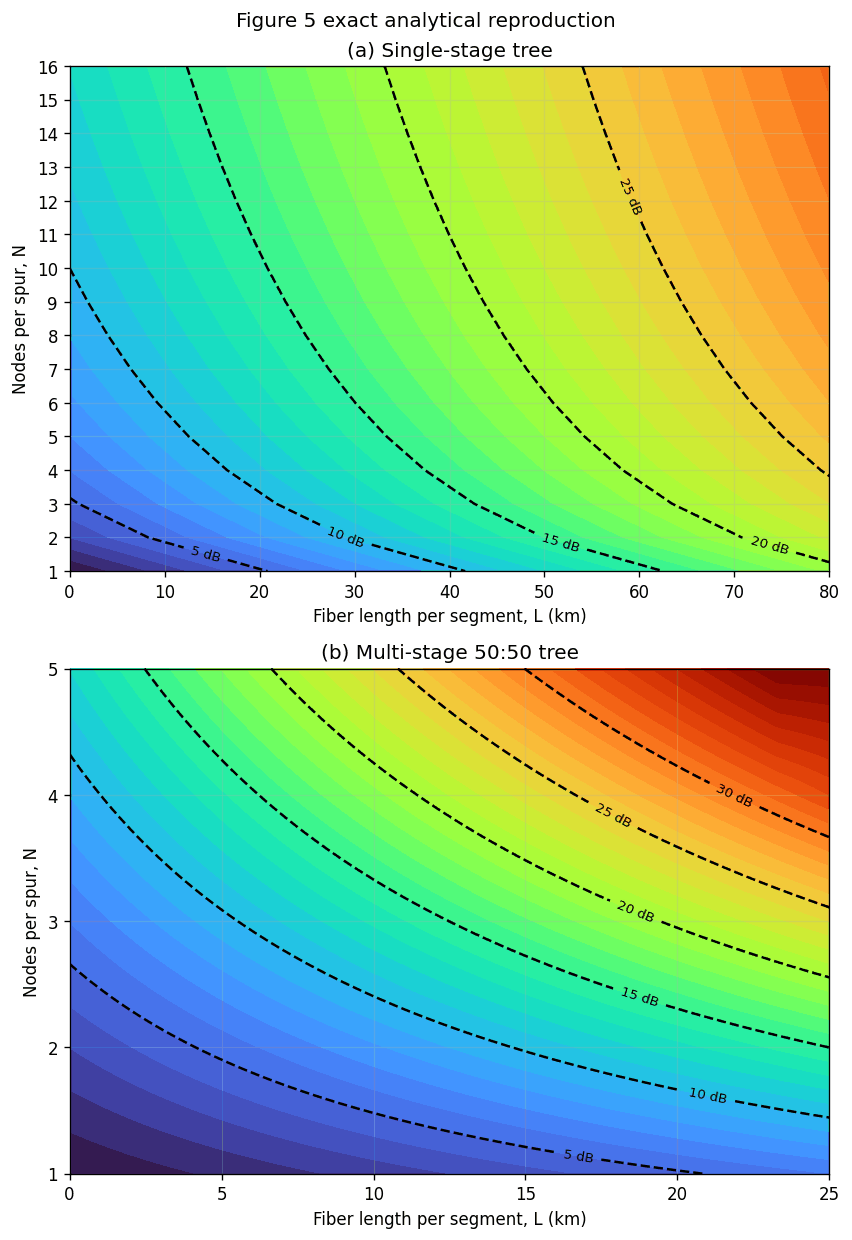

In [11]:
def pb_single(length_km, nodes, alpha=P.attenuation_db_per_km):
    return alpha*length_km + 10*np.log10(nodes)

def pb_multi(length_km, nodes, alpha=P.attenuation_db_per_km):
    return nodes*alpha*length_km + (nodes-1)*10*np.log10(2)

L1 = np.linspace(0, 80, 241)
N1 = np.arange(1, 17)
LL1, NN1 = np.meshgrid(L1, N1)
Z1 = pb_single(LL1, NN1)

L2 = np.linspace(0, 25, 201)
N2 = np.arange(1, 6)
LL2, NN2 = np.meshgrid(L2, N2)
Z2 = pb_multi(LL2, NN2)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 10.5))
fill_levels = np.linspace(0, 40, 41)
axes[0].contourf(LL1, NN1, np.clip(Z1, 0, 40), levels=fill_levels, cmap='turbo')
axes[1].contourf(LL2, NN2, np.clip(Z2, 0, 40), levels=fill_levels, cmap='turbo')
levels1 = [5, 10, 15, 20, 25]
levels2 = [5, 10, 15, 20, 25, 30]
cs1 = axes[0].contour(LL1, NN1, Z1, levels=levels1, colors='k', linestyles='--')
axes[0].clabel(cs1, inline=True, fontsize=8, fmt='%g dB')
cs2 = axes[1].contour(LL2, NN2, Z2, levels=levels2, colors='k', linestyles='--')
axes[1].clabel(cs2, inline=True, fontsize=8, fmt='%g dB')
axes[0].set(title='(a) Single-stage tree', xlabel='Fiber length per segment, L (km)', ylabel='Nodes per spur, N')
axes[1].set(title='(b) Multi-stage 50:50 tree', xlabel='Fiber length per segment, L (km)', ylabel='Nodes per spur, N')
axes[0].set_yticks(np.arange(1, 17)); axes[1].set_yticks(np.arange(1, 6))
fig.suptitle('Figure 5 exact analytical reproduction')
fig.tight_layout()
plt.show()

print('Single-stage: L=80 km, N=16 ->', round(pb_single(80, 16), 2), 'dB')
print('Multi-stage:  L=25 km, N=5  ->', round(pb_multi(25, 5), 2), 'dB')

## 7. GN 모델 확장 위치 — 재현 그래프에는 미사용

현재 논문은 GN 모델 대신 SCF −8 dBm/SC, HCF 10 dBm/SC의 비선형 hard limit를 사용합니다. 만약 `η` 또는 `γ, β₂, baud rate, channel spacing, ASE`가 제공되면 아래 식으로 hard limit를 물리 기반 QoT 제약으로 교체할 수 있습니다.

\[
P_{NLI}=N_{span}\eta P_{ch}^{3},\qquad
SNR=\frac{P_{ch}}{P_{ASE}+P_{NLI}}.
\]

아래 셀은 GN 계수 `η`가 주어졌을 때의 연결 지점을 보여주는 예시이며 Figures 2–5 계산에는 사용하지 않습니다.

In [12]:
def gn_snr_db(pch_dbm, eta_w_inv2, pase_w, n_spans=1):
    p_w = 1e-3 * 10**(np.asarray(pch_dbm)/10)
    pnli_w = n_spans * eta_w_inv2 * p_w**3
    return 10*np.log10(p_w/(pase_w + pnli_w))

def gn_power_limit_dbm(eta_w_inv2, pase_w, snr_req_db, n_spans=1,
                       search_dbm=(-30, 20), points=20001):
    p = np.linspace(*search_dbm, points)
    feasible = p[gn_snr_db(p, eta_w_inv2, pase_w, n_spans) >= snr_req_db]
    return np.nan if feasible.size == 0 else feasible.max()

print('GN extension functions are ready; paper-specific eta/ASE values are intentionally not guessed.')

GN extension functions are ready; paper-specific eta/ASE values are intentionally not guessed.


## 8. 결론과 재현 한계

1. Fig. 2와 Fig. 5는 공개 수식으로 직접 계산되므로 정확 재현 대상입니다.
2. Fig. 3과 Fig. 4는 논문의 공개된 Table I, 22개 EDFA 후보, MILP coupler-ratio 선택, power imbalance 및 amplifier-output/nonlinearity cap을 이용한 독립 재현입니다. 논문에 장비별 EDFA gain 범위가 없어 0–30 dB의 느슨한 수치 경계를 두되 출력 cap을 물리 상한으로 사용합니다.
3. 원 저자의 10개 topology link-length 원자료와 전체 Julia/JuMP 제약식이 공개되지 않아 곡선별 완전 일치는 보장할 수 없습니다. 노트북은 이 누락값을 paper curve에 맞춰 역보정하지 않고, 평균 12 km 고정-seed ensemble로 대체합니다.
4. 그래프의 점선·음영으로 표시한 15.8 dB, 26–35 dB, 11–13 amplifier 및 약 10 dB는 논문 본문에 명시된 **검증 기준**이며 MILP 입력이 아닙니다.

In [13]:
# 계산 결과를 후속 분석용 CSV로 저장합니다(Colab session 내부).
fig3.to_csv('fig3_milp_reproduction.csv', index=False)
fig4.to_csv('fig4_hybrid_difference_reproduction.csv', index=False)
validation_fig3.to_csv('fig3_text_anchor_validation.csv', index=False)
print('Saved: fig3_milp_reproduction.csv, fig4_hybrid_difference_reproduction.csv, fig3_text_anchor_validation.csv')

Saved: fig3_milp_reproduction.csv, fig4_hybrid_difference_reproduction.csv, fig3_text_anchor_validation.csv
